# **Building a Gender Classification Model**

---

### Project Type - Classification - Deployment

### Contribution - Individual - Aiman Sahay

---

## **PROJECT SUMMARY**

This project focuses on building and deploying an end-to-end **gender classification system** using machine learning and natural language processing (NLP) techniques. The objective was to accurately classify a user’s gender based on structured attributes such as age and company, along with unstructured textual data such as names.

The dataset used for this project consisted of user-level information, including features like name, age, company, and gender. Initial data preprocessing ensured data quality by checking for missing values, duplicates, and inconsistencies. The target variable, gender, was encoded using label encoding, while categorical features such as company were transformed using one-hot encoding to make them suitable for machine learning models.

A key highlight of this project is the use of **NLP-based feature engineering**. Instead of treating names as simple categorical variables, a **Sentence Transformer model** was used to convert names into meaningful numerical embeddings. These embeddings capture semantic and linguistic patterns in names that can be indicative of gender. Since embeddings are high-dimensional, **Principal Component Analysis (PCA)** was applied to reduce dimensionality while retaining the most important information. These transformed text features were then combined with structured numerical features to create a comprehensive feature set.

Multiple classification algorithms were implemented and evaluated, including **Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting**. Model performance was assessed using evaluation metrics such as accuracy, confusion matrix, classification report (precision, recall, F1-score), and ROC-AUC curves. Careful comparison of training and validation accuracy was also conducted to identify potential overfitting.

Among all the models tested, **Logistic Regression** was selected as the benchmark and final model after hyperparameter tuning using GridSearchCV. Despite being a relatively simple model, it demonstrated strong performance and generalization capability, making it a reliable choice for this classification task. The final model achieved a balanced trade-off between bias and variance, ensuring consistent performance on unseen data.

From a deployment perspective, the project was designed to simulate a real-world production setup. The trained model, along with preprocessing components such as the scaler, PCA transformer, and encoder, was serialized using pickle for reuse. A **Flask-based REST API** was developed to serve predictions, allowing users to input data and receive gender classification results in real time.

To enhance portability and deployment consistency, the application was **containerized using Docker**, enabling it to run seamlessly across different environments. Additionally, a **Streamlit web application** was built to provide an interactive and user-friendly interface for end users, allowing them to input details and visualize predictions without interacting directly with the API.

This project demonstrates a complete machine learning pipeline; from advanced feature engineering using NLP techniques to model building, evaluation, and deployment. It highlights the integration of data science and MLOps practices to create scalable, user-facing applications capable of delivering real-time predictions.

---

## **GITHUB LINK**

https://github.com/AimanSahay/MLOps-Project

---
## **PROJECT OBJECTIVE**

Deploy a classification model to categorize a user's gender.

---
# ***Let's Begin !***

#### **Importing Necessary Libraries**

In [224]:
# !pip install sentence-transformers
# !pip uninstall tensorflow keras -y
# !pip install torch sentence-transformers

In [114]:
import numpy as np
import pandas as pd
import seaborn as sns
import random
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_curve, auc
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,classification_report, precision_recall_curve, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

---
## **Data Loading**

In [171]:
flight=pd.read_csv("C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Data_Files/travel_capstone/flights.csv",on_bad_lines='skip')
hotel=pd.read_csv("C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Data_Files/travel_capstone/hotels.csv",on_bad_lines='skip')
user=pd.read_csv("C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Data_Files/travel_capstone/users.csv",on_bad_lines='skip')

### Dataset First view

In [172]:
flight.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [173]:
hotel.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [174]:
user.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


---
### **Data Preprocessing**

In [175]:
# Dataset Rows & Columns count
user.shape

(1340, 5)

In [120]:
# Check for missing values
user.isnull().sum()

code       0
company    0
name       0
gender     0
age        0
dtype: int64

In [176]:
# Check for duplicate rows
user.duplicated().sum()

np.int64(0)

In [177]:
# Check for data types of different features
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


In [178]:
user['gender'].value_counts()

gender
male      452
female    448
none      440
Name: count, dtype: int64

**Summary**

1. The **gender** feature, our dependent variable, will be encoded using a **label encoder** to convert its categorical values (i.e., male and female) into numeric representations suitable for the classification model. Here, 1 will denote male, and 0 will denote female.

2. The **company** feature holds a non-ordinal relationship, meaning the categories do not have a meaningful order. Therefore, using **One-Hot Encoding** is the best option to transform its categorical values into a numeric format suitable for the model.

3. For the **name** feature, we will apply an NLP model, such as a **sentence transformer**, to extract meaningful embeddings. Additionally, we will use **PCA (Principal Component Analysis)** to reduce dimensionality before using it in the classification model.

In [179]:
# Statistics of numerical features
user.describe()

,code,age
count,1340.000000,1340.000000
mean,669.500000,42.742537
std,386.968991,12.869779
min,0.000000,21.000000
25%,334.750000,32.000000
50%,669.500000,42.000000
75%,1004.250000,54.000000
max,1339.000000,65.000000


In [180]:
# Statistics of categorical features
user.describe(include=['object', 'category'])

,company,name,gender
count,1340,1340,1340
unique,5,1338,3
top,4You,Charlotte Johnson,male
freq,453,2,452


In [181]:
user['company'].value_counts()

company
4You             453
Acme Factory     261
Wonka Company    237
Monsters CYA     195
Umbrella LTDA    194
Name: count, dtype: int64

In [182]:
user.sample(n=5)

,code,company,name,gender,age
292,292,4You,Theodore Carter,none,36
315,315,4You,Alfred Atkinson,none,61
80,80,4You,Elissa Hubbard,female,45
1221,1221,Umbrella LTDA,Clifton Phillips,male,33
1109,1109,Acme Factory,Gregory Fiorini,male,28


In [183]:
user[user['name']=='Charlotte Johnson']

,code,company,name,gender,age
316,316,4You,Charlotte Johnson,female,64
496,496,Monsters CYA,Charlotte Johnson,none,51


In [184]:
user['gender'].value_counts()

gender
male      452
female    448
none      440
Name: count, dtype: int64

In [185]:
user_df=user[(user['gender']=='male') | (user['gender']=='female') ]

In [186]:
# user_df = user.copy()

In [187]:
one_hot_encoder = OneHotEncoder()

# One-Hot Encode the 'company' feature
company_encoded = one_hot_encoder.fit_transform(user_df[['company']]).toarray()

# Add one-hot encoded columns back to the DataFrame
company_encoded_df = pd.DataFrame(company_encoded, columns=one_hot_encoder.get_feature_names_out(['company']))
user_df = pd.concat([user_df, company_encoded_df], axis=1)

# Encode the 'gender' feature using Label Encoding
label_encoder = LabelEncoder()
user_df['gender_encoded'] = label_encoder.fit_transform(user_df['gender'])


In [188]:
user_df.head()

,code,company,name,gender,age,company_4You,company_Acme Factory,company_Monsters CYA,company_Umbrella LTDA,company_Wonka Company,gender_encoded
0,0.0,4You,Roy Braun,male,21.0,1.0,0.0,0.0,0.0,0.0,1
1,1.0,4You,Joseph Holsten,male,37.0,1.0,0.0,0.0,0.0,0.0,1
2,2.0,4You,Wilma Mcinnis,female,48.0,1.0,0.0,0.0,0.0,0.0,0
3,3.0,4You,Paula Daniel,female,23.0,1.0,0.0,0.0,0.0,0.0,0
4,4.0,4You,Patricia Carson,female,44.0,1.0,0.0,0.0,0.0,0.0,0


In [189]:
# user_df['gender_encoded'].value_counts()

In [74]:
# user_df['gender'].value_counts()

In [75]:
# user_df.shape

In [190]:
# Initialize the SentenceTransformer model
model = SentenceTransformer('flax-sentence-embeddings/all_datasets_v4_MiniLM-L6')
# model = SentenceTransformer('all-MiniLM-L6-v2')

In [191]:
# Handle missing values and ensure all are strings
text_columns = ['name']
for column in text_columns:
    user_df[column] = user_df[column].fillna('').astype(str)  # Replace NaN with empty string

# Encode text columns into embeddings
for column in text_columns:
    user_df[column + '_embedding'] = user_df[column].apply(lambda text: model.encode(text))

# Concatenate embeddings into a single feature vector (if required)
text_embeddings = user_df[[column + '_embedding' for column in text_columns]].values.tolist()


In [192]:
# Update numerical features to include one-hot encoded company columns
numerical_features = ['code', 'age'] + [col for col in user_df.columns if col.startswith('company_')]

# Extract numerical features
X_numerical = user_df[numerical_features].values

# Apply PCA to text embeddings
n_components = 23  # Adjust the number of components as needed
pca = PCA(n_components=n_components)
text_columns = ['name']

# Create an empty array to store PCA-transformed embeddings
text_embeddings_pca = np.empty((len(user_df), n_components * len(text_columns)))

for i, column in enumerate(text_columns):
    embeddings = np.array(user_df[column + '_embedding'].tolist())
    embeddings_pca = pca.fit_transform(embeddings)
    text_embeddings_pca[:, i * n_components:(i + 1) * n_components] = embeddings_pca

# Combine PCA-transformed text embeddings and numerical features
X = np.hstack((text_embeddings_pca, X_numerical))

# Target variable
y = user_df['gender_encoded']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [193]:
numerical_features

['code',
 'age',
 'company_4You',
 'company_Acme Factory',
 'company_Monsters CYA',
 'company_Umbrella LTDA',
 'company_Wonka Company']

In [194]:
user_df.head()

,code,company,name,gender,age,company_4You,company_Acme Factory,company_Monsters CYA,company_Umbrella LTDA,company_Wonka Company,gender_encoded,name_embedding
0,0.0,4You,Roy Braun,male,21.0,1.0,0.0,0.0,0.0,0.0,1,"[-0.08575874, 0.10470479, -0.058521215, 0.0501..."
1,1.0,4You,Joseph Holsten,male,37.0,1.0,0.0,0.0,0.0,0.0,1,"[-0.10680759, 0.1019951, -0.050716557, -0.0085..."
2,2.0,4You,Wilma Mcinnis,female,48.0,1.0,0.0,0.0,0.0,0.0,0,"[-0.04034248, -0.010345596, -0.009061363, -0.0..."
3,3.0,4You,Paula Daniel,female,23.0,1.0,0.0,0.0,0.0,0.0,0,"[-0.05217372, -0.003386118, -0.012928225, -0.0..."
4,4.0,4You,Patricia Carson,female,44.0,1.0,0.0,0.0,0.0,0.0,0,"[-0.042972144, -0.0023808037, -0.0005046217, -..."


In [195]:
len(text_embeddings)

1206

In [151]:
# user_df['gender'].value_counts()

In [152]:
# y.value_counts()

In [196]:
print("Shape of X:", X.shape)

Shape of X: (1206, 30)


In [197]:
user_df[numerical_features].values

array([[ 0., 21.,  1., ...,  0.,  0.,  0.],
       [ 1., 37.,  1., ...,  0.,  0.,  0.],
       [ 2., 48.,  1., ...,  0.,  0.,  0.],
       ...,
       [nan, nan,  0., ...,  0.,  1.,  0.],
       [nan, nan,  0., ...,  0.,  1.,  0.],
       [nan, nan,  0., ...,  0.,  1.,  0.]])

In [198]:
# Calculate missing values in percentage for training and test data
train_missing_percentage = pd.DataFrame(X_train).isnull().sum()/len(pd.DataFrame(X_train))*100
test_missing_percentage = pd.DataFrame(X_test).isnull().sum() * 100

print("Missing values in training data (percentage):\n", train_missing_percentage)
print("Missing values in test data (percentage):\n", test_missing_percentage)


Missing values in training data (percentage):
 0      0.000000
1      0.000000
2      0.000000
3      0.000000
4      0.000000
5      0.000000
6      0.000000
7      0.000000
8      0.000000
9      0.000000
10     0.000000
11     0.000000
12     0.000000
13     0.000000
14     0.000000
15     0.000000
16     0.000000
17     0.000000
18     0.000000
19     0.000000
20     0.000000
21     0.000000
22     0.000000
23    26.452282
24    26.452282
25    25.518672
26    25.518672
27    25.518672
28    25.518672
29    25.518672
dtype: float64
Missing values in test data (percentage):
 0        0
1        0
2        0
3        0
4        0
5        0
6        0
7        0
8        0
9        0
10       0
11       0
12       0
13       0
14       0
15       0
16       0
17       0
18       0
19       0
20       0
21       0
22       0
23    5100
24    5100
25    6000
26    6000
27    6000
28    6000
29    6000
dtype: int64


---
## **Model Building**

### **Logistic Regression**

Accuracy: 0.987603305785124

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98        94
           1       0.98      0.99      0.98        97
           2       1.00      1.00      1.00        51

    accuracy                           0.99       242
   macro avg       0.99      0.99      0.99       242
weighted avg       0.99      0.99      0.99       242



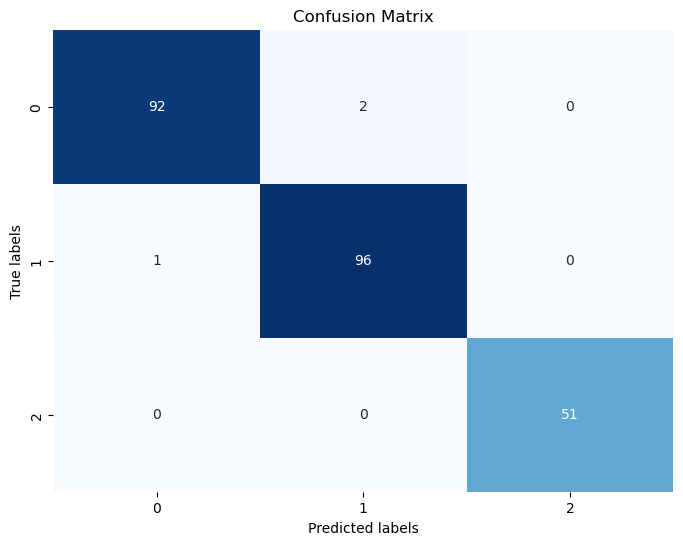

In [200]:
# Impute missing values
imputer = SimpleImputer(strategy='median')  
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Initialize and fit the Logistic Regression model
lr_classifier = LogisticRegression(random_state=42)
lr_classifier.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_classifier.predict(X_test)

# Accuracy
accuracy = lr_classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

# Classification report
report = classification_report(y_test, y_pred_lr)
print("\nClassification Report:\n", report)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


In [201]:
# Predictions on training and validation sets
y_train_pred = lr_classifier.predict(X_train)
y_val_pred = lr_classifier.predict(X_test)

# Calculate accuracy on training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_test, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

# Check if overfitting
if train_accuracy > val_accuracy:
    print("The model is overfitting.")
else:
    print("The model is not overfitting.")


Training Accuracy: 0.9802904564315352
Validation Accuracy: 0.987603305785124
The model is not overfitting.


In [202]:
model_result = pd.DataFrame([['Logistic Regression Baseline', train_accuracy,val_accuracy]],
               columns = ['Model', 'Train accuracy', 'Validation accuracy'])

model_result

,Model,Train accuracy,Validation accuracy
0,Logistic Regression Baseline,0.98029,0.987603


### **Decision Tree Classifier**

Accuracy: 0.9669421487603306

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        94
           1       0.96      0.96      0.96        97
           2       1.00      1.00      1.00        51

    accuracy                           0.97       242
   macro avg       0.97      0.97      0.97       242
weighted avg       0.97      0.97      0.97       242



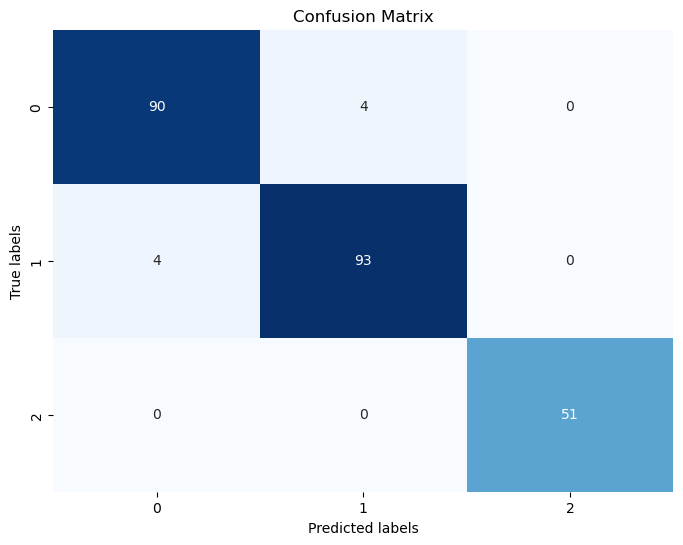

In [203]:
# Initialize a Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
dt_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_dt = dt_classifier.predict(X_test)

# Calculate and print accuracy
accuracy = dt_classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

# Generate a classification report
report = classification_report(y_test, y_pred_dt)
print("\nClassification Report:\n", report)

cm = confusion_matrix(y_test, y_pred_dt)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()



In [204]:
# Predictions on training and validation sets
y_train_pred = dt_classifier.predict(X_train)
y_val_pred = dt_classifier.predict(X_test)

# Calculate accuracy on training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_test, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

# Check if overfitting
if train_accuracy > val_accuracy:
    print("The model is overfitting.")
else:
    print("The model is not overfitting.")

Training Accuracy: 1.0
Validation Accuracy: 0.9669421487603306
The model is overfitting.


In [205]:
model = pd.DataFrame([['Decision Tree Classifier Baseline', train_accuracy,val_accuracy]],
               columns = ['Model', 'Train accuracy', 'Validation accuracy'])
model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,Train accuracy,Validation accuracy
0,Logistic Regression Baseline,0.98029,0.987603
1,Decision Tree Classifier Baseline,1.00000,0.966942


### **Random Forest Classifier**

In [206]:
# Initialize a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_classifier.predict(X_test)

Accuracy: 0.9834710743801653

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        94
           1       0.98      0.98      0.98        97
           2       1.00      1.00      1.00        51

    accuracy                           0.98       242
   macro avg       0.99      0.99      0.99       242
weighted avg       0.98      0.98      0.98       242



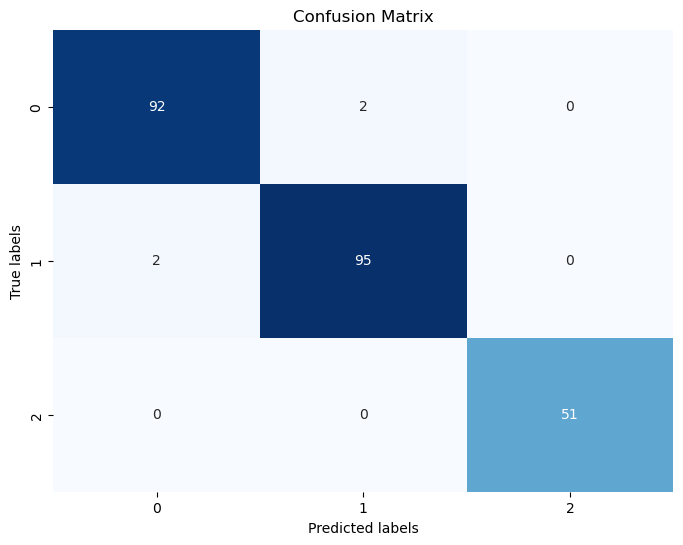

In [207]:
# Calculate and print accuracy
accuracy = rf_classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

# Generate a classification report
report = classification_report(y_test, y_pred_rf)
print("\nClassification Report:\n", report)

cm = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [208]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model on the training set
rf_classifier.fit(X_train, y_train)

# Predictions on training and validation sets
y_train_pred = rf_classifier.predict(X_train)
y_val_pred = rf_classifier.predict(X_val)

# Calculate accuracy on training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

# Check if overfitting
if train_accuracy > val_accuracy:
    print("The model is overfitting.")
else:
    print("The model is not overfitting.")

Training Accuracy: 1.0
Validation Accuracy: 0.987603305785124
The model is overfitting.


In [209]:
model = pd.DataFrame([['Random Forest Baseline', train_accuracy,val_accuracy]],
               columns = ['Model', 'Train accuracy', 'Validation accuracy'])
model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,Train accuracy,Validation accuracy
0,Logistic Regression Baseline,0.98029,0.987603
1,Decision Tree Classifier Baseline,1.00000,0.966942
2,Random Forest Baseline,1.00000,0.987603


### **Gradient Boosting Classifier**

Accuracy: 0.6363636363636364

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.35      0.43        94
           1       0.53      0.72      0.61        97
           2       1.00      1.00      1.00        51

    accuracy                           0.64       242
   macro avg       0.69      0.69      0.68       242
weighted avg       0.64      0.64      0.62       242



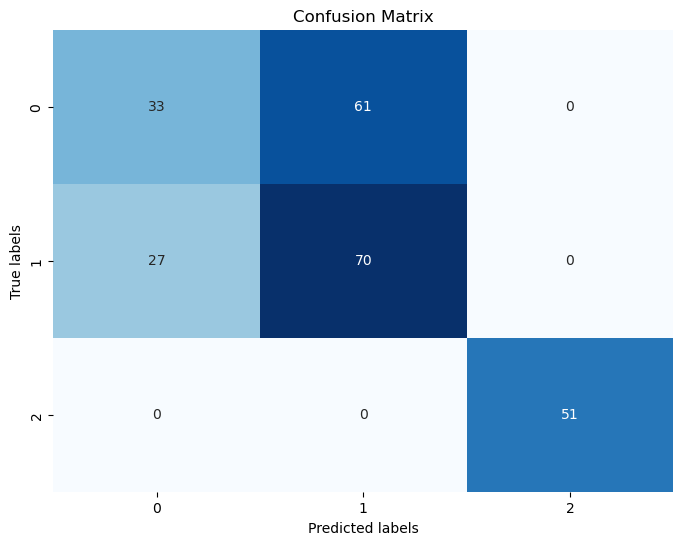

In [214]:
# Initialize the imputer to fill NaN values with the mean of the column
imputer = SimpleImputer(strategy='mean')

# Fit the imputer and transform the training and test data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Now fit the model with the imputed data
gb_classifier.fit(X_train_imputed, y_train)

# Make predictions and evaluate
y_pred_gb = gb_classifier.predict(X_test_imputed)
accuracy = gb_classifier.score(X_test_imputed, y_test)
print("Accuracy:", accuracy)

# Generate classification report
report = classification_report(y_test, y_pred_gb)
print("\nClassification Report:\n", report)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


In [216]:
# Predictions on training and validation sets
y_train_pred = gb_classifier.predict(X_train_imputed)
y_val_pred = gb_classifier.predict(X_test_imputed)

# Calculate accuracy on training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_test, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

# Check for overfitting
if train_accuracy > val_accuracy:
    print("The model is overfitting.")
else:
    print("The model is not overfitting.")


Training Accuracy: 1.0
Validation Accuracy: 0.6363636363636364
The model is overfitting.


In [217]:
model = pd.DataFrame([['XGBoost Classifier Baseline', train_accuracy,val_accuracy]],
               columns = ['Model', 'Train accuracy', 'Validation accuracy'])
model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,Train accuracy,Validation accuracy
0,Logistic Regression Baseline,0.98029,0.987603
1,Decision Tree Classifier Baseline,1.00000,0.966942
2,Random Forest Baseline,1.00000,0.987603
3,XGBoost Classifier Baseline,1.00000,0.636364


### **ROC-AUC Curve**

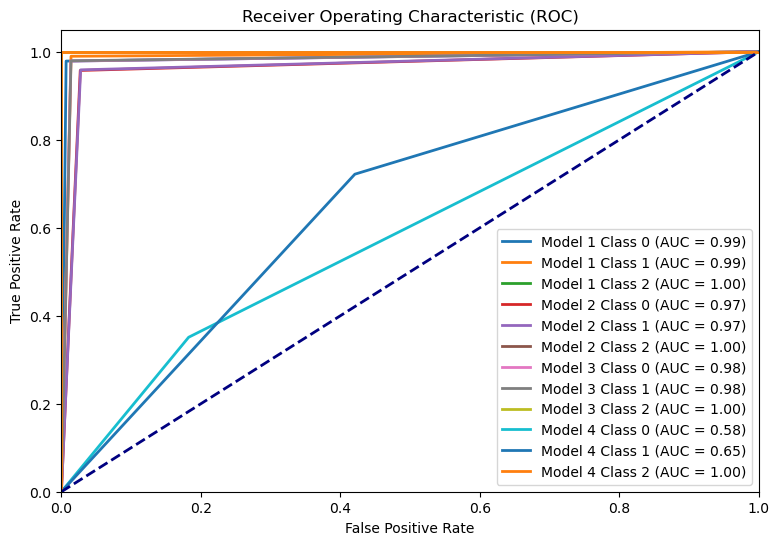

In [218]:
# Create a dictionary to store the classification reports and predictions
model_reports = {}

# Train and evaluate each model
model_reports['Random Forest'] = classification_report(y_test, y_pred_rf)
model_reports['Gradient Boosting'] = classification_report(y_test, y_pred_gb)
model_reports['Decision Tree'] = classification_report(y_test, y_pred_dt)
model_reports['Logistic Regression'] = classification_report(y_test, y_pred_lr)

# Save the classification reports to a CSV file
reports_df = pd.DataFrame.from_dict(model_reports, orient='index', columns=['Classification Report'])
reports_df.to_csv('classification_reports.csv')

# Binarize the output labels for ROC curve calculation (multiclass case)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Initialize lists to store fpr, tpr, and roc_auc for each model
fpr_list = []
tpr_list = []
roc_auc_list = []

# Compute ROC curve and ROC AUC for each model (for each class)
for y_pred in [y_pred_lr, y_pred_dt, y_pred_rf, y_pred_gb]:
    fpr = {}
    tpr = {}
    roc_auc = {}

    # For each class, calculate ROC curve and AUC
    for i in range(y_test_bin.shape[1]):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred == i)
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Store fpr, tpr, and roc_auc
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    roc_auc_list.append(roc_auc)

# Plot ROC curves for each model
plt.figure(figsize=(9, 6))
for i, roc_auc in enumerate(roc_auc_list):
    for j in roc_auc:
        plt.plot(fpr_list[i][j], tpr_list[i][j], lw=2, label=f'Model {i+1} Class {j} (AUC = {roc_auc[j]:0.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()


### **Benchmark Model Selection and Hyperparameter Tuning**

**Logistic Regression is our Benchmark model**

Best Hyperparameters: {'C': 4, 'penalty': 'l1', 'solver': 'liblinear'}
Tuned Model Accuracy: 0.9710743801652892

Tuned Model Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        94
           1       0.95      0.98      0.96        97
           2       1.00      1.00      1.00        51

    accuracy                           0.97       242
   macro avg       0.98      0.98      0.98       242
weighted avg       0.97      0.97      0.97       242



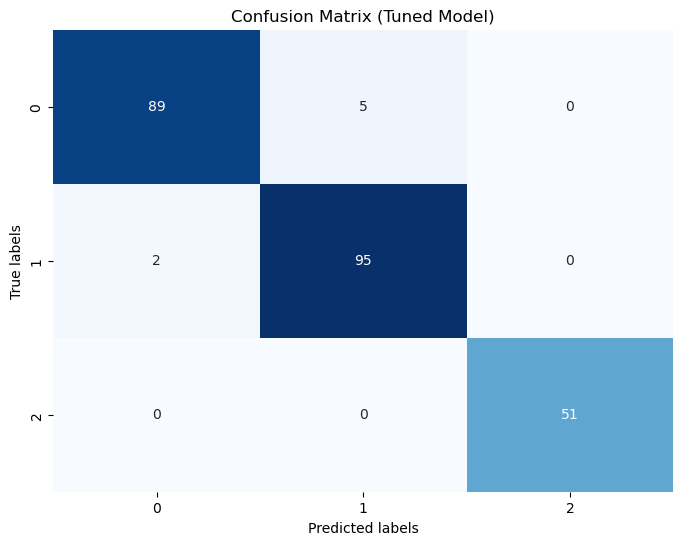

In [219]:
# Handle missing values by imputing with the mean value
imputer = SimpleImputer(strategy='median')

# Impute the training and testing data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Now define the hyperparameters for tuning using GridSearchCV
param_grid = {
    'penalty': ['l1', 'l2'],  # Regularization penalty
    'C': [0.001, 0.01, 0.1, 1, 4, 100],  # Inverse of regularization strength
    'solver': ['liblinear', 'saga']  # Algorithm to use in the optimization problem
}

# Initialize Logistic Regression Classifier
lr_classifier = LogisticRegression(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(lr_classifier, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV to the imputed training data
grid_search.fit(X_train_imputed, y_train)

# Print the best hyperparameters found
print("Best Hyperparameters:", grid_search.best_params_)

# Use the best model found by GridSearchCV
best_lr_classifier = grid_search.best_estimator_

# Make predictions on the imputed test data using the best model
y_pred_lr_tuned = best_lr_classifier.predict(X_test_imputed)

# Calculate and print accuracy using the best model
accuracy_tuned = best_lr_classifier.score(X_test_imputed, y_test)
print("Tuned Model Accuracy:", accuracy_tuned)

# Generate a classification report using the tuned model
report_tuned = classification_report(y_test, y_pred_lr_tuned)
print("\nTuned Model Classification Report:\n", report_tuned)

# Calculate confusion matrix using the tuned model
cm_tuned = confusion_matrix(y_test, y_pred_lr_tuned)

# Plot confusion matrix using the tuned model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Tuned Model)')
plt.show()


In [102]:
# Train the model on the imputed training set
best_lr_classifier.fit(X_train_imputed, y_train)

# Predictions on the imputed training and validation sets
y_train_pred = best_lr_classifier.predict(X_train_imputed)
y_val_pred = best_lr_classifier.predict(X_val_imputed)

# Calculate accuracy on the training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_test, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)


Training Accuracy: 0.9740663900414938
Validation Accuracy: 0.9834710743801653


**Pickle the Benchmark model**

In [220]:
import pickle

# Pickle the tuned logistic regression model
with open('models/tuned_logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(best_lr_classifier, file)
    

In [221]:
# Pickle the Scaler model
with open('models/scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [222]:
# Pickle the PCA model
with open('models/pca.pkl', 'wb') as file:
    pickle.dump(pca, file)

In [223]:
# Pickle the one hot encoder
with open('models/ohe.pkl', 'wb') as file:
    pickle.dump(one_hot_encoder, file)

---

## **Conclusion**

This project successfully demonstrates the integration of machine learning and NLP techniques to solve a real-world classification problem. By leveraging name embeddings through sentence transformers and combining them with structured features, the model was able to capture deeper patterns for accurate gender classification. Among the models evaluated, Logistic Regression proved to be the most effective, offering strong performance with good generalization.

In addition to model development, the project emphasizes practical deployment through Flask, Docker, and Streamlit, making the solution accessible, scalable, and user-friendly. The project showcases a complete end-to-end pipeline; from data preprocessing and feature engineering to deployment, highlighting the importance of building not just accurate models, but production-ready machine learning systems.

---